Using the Fresnel module
=====================

In this section, we will describe how to use the `Fresnel` module of `pySCATMECH`. This module defines the classes `OpticalFunction`, `Film`, and `FilmStack`.  The last can be used to calculate the reflectance and transmittance of a stack of thin films on a substrate.

We start by importing the package and importing `matplotlib`, which we use for some graphing:

In [1]:
from pySCATMECH.fresnel import *

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

OpticalFunction class
-------------------------------
The optical properties of a material can be stored with the class `OpticalFunction`.  Here we create some materials by defining their optical functions. An optical function can be obtained from a file containing a table of wavelengths ($\lambda$), optical constant ($n$), and extinction coefficient ($k$). Or it can be defined as a complex number $n+\mathrm{i}k$. Since optical functions are a function of wavelength, one can create them as a function. If you create them as a function, they need to be tabulated at discrete wavelengths in order for SCATMECH to use them as interpolation tables. Note that doing that will create temporary files.

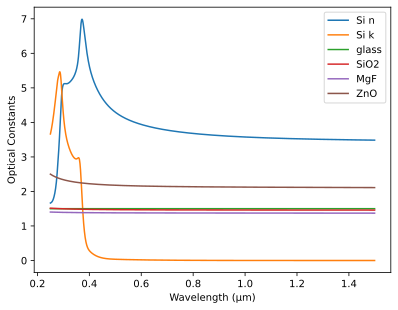

In [2]:
wavelengths = np.arange(0.2,2.5,0.01)

# The following looks for a file named "silicon"
# Assume that "silicon" exists on your computer...
silicon = OpticalFunction("silicon") 

# A fixed real index:
glass = OpticalFunction(1.5) 

# A metal, i.e., a complex index of refraction:
aMetal = OpticalFunction(1.4+2.1j)

# A material with a Cauchy dispersion, given as a lambda function
# When providing a function, one must provide an iterable list of wavelengths because 
# the function is tabulated.
SiO2 = OpticalFunction(lambda L: 1.4580 + 0.00354/L**2, wavelengths)

# A couple materials with Sellmeier functions...
MgF = OpticalFunction(lambda L: math.sqrt(1+0.48755108*L**2/(L**2-0.04338408**2)
                                           +0.39875031*L**2/(L**2-0.09461442**2)
                                           +2.3120353*L**2/(L**2-23.793604**2)),
                                             wavelengths)

ZnO = OpticalFunction(lambda L: math.sqrt(1+1.347091*L**2/(L**2-0.062543**2)
                                           +2.117788*L**2/(L**2-0.166739**2)
                                           +9.452943*L**2/(L**2-24.320570**2)),
                                             wavelengths)

# It is useful to have one for vacuum:
vacuum = OpticalFunction(1)

wavelengths = np.arange(0.25,1.5,0.001)

# Plot the curves...
plt.figure()
plt.plot(wavelengths, [silicon(w).real for w in wavelengths], label="Si n")
plt.plot(wavelengths, [silicon(w).imag for w in wavelengths], label="Si k")
plt.plot(wavelengths, [glass(w) for w in wavelengths], label="glass")
plt.plot(wavelengths, [SiO2(w) for w in wavelengths], label="SiO2")
plt.plot(wavelengths, [MgF(w) for w in wavelengths], label="MgF")
plt.plot(wavelengths, [ZnO(w) for w in wavelengths], label="ZnO")
plt.xlabel("Wavelength (µm)")
plt.ylabel("Optical Constants")
plt.legend()
plt.show()

Film class
----------

The class `Film` handles the properties of a film, namely, its optical function and its thickness.  There are basically two ways to create a `Film`: with a thickness (length) or with an optical thickness (length relative to wavelength in the material).  (SCATMECH assumes lengths are in micrometers, although any user can use another unit, provided that unit is consistently used everywhere.)

In [3]:
# Create a film of ZnO (defined above) of thickness 0.5 micrometers...
film1 = Film(ZnO, thickness = 0.5)

# Create a quarter-wave thickness of ZnO for wavelength 0.5 micrometers...
film2 = Film(ZnO, waves = 1/4, wavelength = 0.5)

# create a quarter-wave thickness of ZnO for wavelength 0.5 micrometers for 45 degrees incidence...
film3 = Film(ZnO, waves = 1/4, wavelength = 0.5, angle = 45*deg)

One of the properties of `Film` is that we can multiply a film by a scalar to obtain a film, say, twice as thick. This feature can be used to create high/low stacks in an intuitive way. FOr example, we can create a notch filter.

In [4]:
H = Film(ZnO, waves = 1/4, wavelength = 0.5)
L = Film(MgF, waves = 1/4, wavelength = 0.5)

notch_filter = 5*[H,L] + [2*H] + 5*[L,H]

FilmStack class
----------------------

The `FilmStack` class handles a stack of films. Most importantly, it allows us to calculate the reflection or transmission properties for radiation incident on one material to another with a stack of films in between. We will start our demonstration of the `FilmStack` class with an empty one. 

The `FilmStack` methods that return reflection or transmission properties take four or five parameters. 
* The angle of incidence in radians
* The wavelength (as measured in vacuum)
* The `OpticalFunction` for the medium the radiation is incident from
* The `OpticalFunction` for the medium the radiation will transmit to
* Optional: a string '12', '21', '12i', or '21i'. The default is '12', which means that the stack of films is to be evaluated as if the first `Film` is closest to the medium the radiation will transmit to. '21' means the stack of films is to be evaluated as if the first `Film` is closest to the medium the radiation is incident from. The 'i' indicates that the angle is expressed as the incident angle in the incident medium. By default (no 'i'), the angle is expressed as a vacuum angle.

So, let's see what the 60° reflectance of silicon is at 0.532 µm.  

In [5]:
stack = FilmStack()

wavelength = 0.500 

# Return a Jones matrix
r = stack.reflectionCoefficient(60*deg, wavelength, vacuum, silicon)
print("Jones matrix = \n",r,"\n")

# Return a Mueller matrix
R = stack.R(60*deg, wavelength, vacuum, silicon)
print("Mueller matrix = \n",R,"\n")

# Return the s and p reflectance
Rs = stack.Rs(60*deg, wavelength, vacuum, silicon) 
Rp = stack.Rp(60*deg, wavelength, vacuum, silicon) 
print("Rs = ",Rs,", Rp = ",Rp)

Jones matrix = 
 (((-0.7875336574103252-0.001629630653451164j), 0j), (0j, (0.37351472018980436+0.003391942682930761j))) 

Mueller matrix = 
 [[ 0.37986833  0.24034358  0.          0.        ]
 [ 0.24034358  0.37986833  0.          0.        ]
 [ 0.          0.         -0.29416094  0.00206258]
 [ 0.          0.         -0.00206258 -0.29416094]] 

Rs =  0.6202119172501501 , Rp =  0.13952475147363216


Let's calculate the reflectance of silicon as a function of angle.

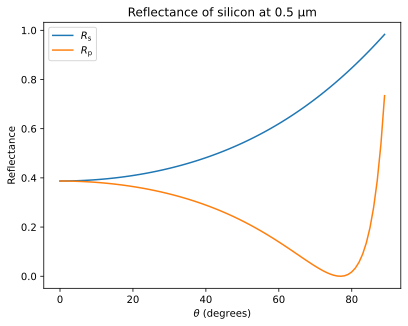

In [6]:
plt.figure()
thetas=[t for t in np.arange(0,90)]
Rs = [stack.Rs(t*deg, wavelength, vacuum, silicon) for t in thetas]
Rp = [stack.Rp(t*deg, wavelength, vacuum, silicon) for t in thetas]
plt.plot(thetas, Rs, label=r"$R_\mathrm{s}$")
plt.plot(thetas, Rp, label=r"$R_\mathrm{p}$")
plt.legend()
plt.title("Reflectance of silicon at " + str(wavelength) + " µm")
plt.xlabel(r"$\theta$ (degrees)")
plt.ylabel("Reflectance")
plt.show()

Let's calculate that reflectance as a function of wavelength for an angle of incidence of 70°.

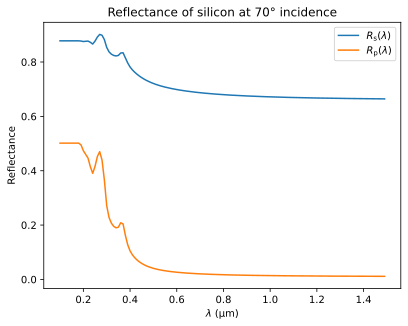

In [7]:
plt.figure()
wavelengths = [L for L in np.arange(0.1, 1.5, 0.01)]
Rs = [stack.Rs(70*deg, wavelength, vacuum, silicon) for wavelength in wavelengths]
Rp = [stack.Rp(70*deg, wavelength, vacuum, silicon) for wavelength in wavelengths]
plt.plot(wavelengths, Rs, label=r"$R_\mathrm{s}(\lambda)$")
plt.plot(wavelengths, Rp, label=r"$R_\mathrm{p}(\lambda)$")
plt.legend()
plt.title("Reflectance of silicon at 70° incidence")
plt.xlabel(r"$\lambda$ (µm)")
plt.ylabel("Reflectance")
plt.show()

Finally, let's calculate the ellipsometric parameters $\Psi$ and $\Delta$ as a function of wavelength.

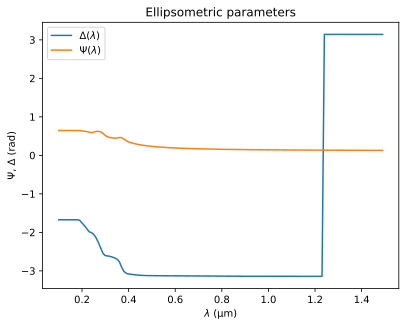

In [8]:
plt.figure()
wavelengths = [L for L in np.arange(0.1, 1.5, 0.01)]
M = [stack.R(70*deg, wavelength, vacuum, silicon) for wavelength in wavelengths]
delta = [(m @ Polarization(angle=45*deg)).delta() for m in M]
psi = [(m @  Polarization(angle=45*deg)).psi() for m in M]
plt.plot(wavelengths, delta, label=r"$\Delta(\lambda)$")
plt.plot(wavelengths, psi, label=r"$\Psi(\lambda)$")
plt.legend()
plt.title("Ellipsometric parameters")
plt.xlabel(r"$\lambda$ (µm)")
plt.ylabel(r'$\Psi$, $\Delta$ (rad)')
plt.show()

That isn't a very interesting film stack. The `grow()` method allows us to grow films on the substrate. The `clean()` method wipes all of the films off. Let's see what the ellipsometric parameters do when we add films of thickness 0 µm, 0.01 µm, 0.02 µm, and 0.03 µm.

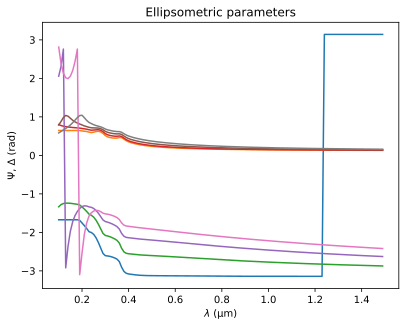

In [9]:
stack = FilmStack()
film = Film(SiO2, thickness = 0.01)
stack.grow(film)

plt.figure()
wavelengths = [L for L in np.arange(0.1, 1.5, 0.01)]

for t in [0., 0.01, 0.02, 0.03]:
    stack.clean()
    stack.grow(Film(SiO2, thickness = t))
    
    M = [stack.R(70*deg, wavelength, vacuum, silicon) for wavelength in wavelengths]
    delta = [(m @ StokesVector(1,0,1,0)).delta() for m in M]
    psi = [(m @ StokesVector(1,0,1,0)).psi() for m in M]
    plt.plot(wavelengths, delta)
    plt.plot(wavelengths, psi)

plt.title("Ellipsometric parameters")
plt.xlabel(r"$\lambda$ (µm)")
plt.ylabel(r'$\Psi$, $\Delta$ (rad)')
plt.show()


We can also look at transmission.  Here is the angle dependence of the transmission of a quarter wave MgF coating on glass.

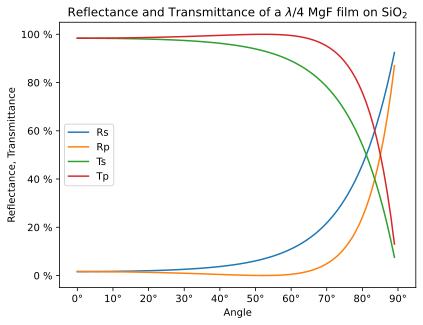

In [10]:
stack = FilmStack()

substrate = SiO2
wavelength = 0.500
stack.grow(Film(MgF, waves=1/4, wavelength=wavelength))

plt.figure()
ax = plt.subplot()
thetas=np.array([t for t in np.arange(0,90)])
Rs = [stack.Rs(theta*deg, wavelength, vacuum, substrate) for theta in thetas]
Rp = [stack.Rp(theta*deg, wavelength, vacuum, substrate) for theta in thetas]
Ts = [stack.Ts(theta*deg, wavelength, vacuum, substrate) for theta in thetas]
Tp = [stack.Tp(theta*deg, wavelength, vacuum, substrate) for theta in thetas]
plt.plot(thetas, Rs, label = "Rs")
plt.plot(thetas, Rp, label = "Rp")
plt.plot(thetas, Ts, label = "Ts")
plt.plot(thetas, Tp, label = "Tp")
plt.legend()
plt.xlim([-5, 95])
plt.xticks(np.linspace(0, 90, 10))
plt.xlabel("Angle")
plt.ylabel("Reflectance, Transmittance")
plt.title(r"Reflectance and Transmittance of a $\lambda/4$ MgF film on SiO$_2$")
class AddDegrees(ticker.Formatter):
    def __call__(self,x,pos):
        return r"$%g \degree$"% x
ax.xaxis.set_major_formatter(AddDegrees())
class AddPercent(ticker.Formatter):
    def __call__(self,x,pos):
        return ("%g" % (x*100))+" %"
ax.yaxis.set_major_formatter(AddPercent())
plt.show()

Let's create with some high-low stacks. Note that we can create `FilmStack` from a list of `Film`. In the following, we create a series of curves containing various numbers of low-high pairs.  A twenty-pair stack, for example, can be created by `FilmStack(20*[L,H])`.

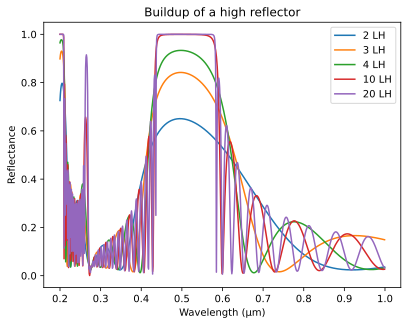

In [11]:
L = Film(MgF, waves=1/4, wavelength=0.500)
H = Film(ZnO, waves=1/4, wavelength=0.500)

substrate = glass

def pltFilm(stack,label=""):
    stack = FilmStack(stack)
    wavelengths = np.arange(0.2, 1.0, 0.001)
    Rs = [stack.Rs(0*deg, L, vacuum, substrate) for L in wavelengths]
    plt.plot(wavelengths, Rs, label=label)

plt.figure()
plt.title("Buildup of a high reflector")
pltFilm(2*[L,H], label="2 LH")
pltFilm(3*[L,H], label="3 LH")
pltFilm(4*[L,H], label="4 LH")
pltFilm(10*[L,H], label="10 LH")
pltFilm(20*[L,H], label="20 LH")
plt.legend()
plt.xlabel("Wavelength (µm)")
plt.ylabel("Reflectance")
plt.show()




Here is a notch filter, which consists of a 2H layer between two high reflectors.

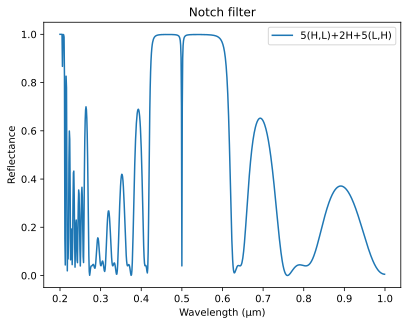

In [12]:
plt.figure()
plt.title("Notch filter")
pltFilm(5*[H,L] + [2*H] + 5*[L,H],"5(H,L)+2H+5(L,H)")
plt.legend()
plt.xlabel("Wavelength (µm)")
plt.ylabel("Reflectance")
plt.show()